In [385]:
import pandas as pd
import sqlite3
pd.set_option('display.width', 1000)

In [386]:
conn = sqlite3.connect("../data/checking-logs.sqlite")


In [387]:
query = """
SELECT timestamp, uid
FROM checker
WHERE status = 'ready' AND uid NOT LIKE 'admin%'
"""
df = pd.read_sql(query, conn)

df['timestamp'] = pd.to_datetime(df['timestamp'])
df['date'] = df['timestamp'].dt.date
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.weekday  # 0=Monday

In [388]:
df['is_weekend'] = df['day_of_week'] >= 5

working_day = df[~df['is_weekend']].groupby(['date', 'hour']).size().reset_index(name='commits')
working_avg = working_day.groupby('hour')['commits'].mean().reindex(range(24)).fillna(0).rename('working_day')
#print(working_avg)


weekend_day = df[df['is_weekend']].groupby(['date', 'hour']).size().reset_index(name='commits')
weekend_avg = weekend_day.groupby('hour')['commits'].mean().reindex(range(24)).fillna(0).rename('weekend_day')

print(weekend_avg)

hour
0      1.000000
1      3.000000
2      0.000000
3      1.000000
4      0.000000
5      1.000000
6      0.000000
7      2.500000
8      4.000000
9      2.166667
10     3.750000
11    12.000000
12     5.166667
13     9.500000
14     6.571429
15     7.625000
16     7.600000
17     4.142857
18     5.285714
19     7.000000
20     7.000000
21     5.428571
22     5.166667
23     3.600000
Name: weekend_day, dtype: float64


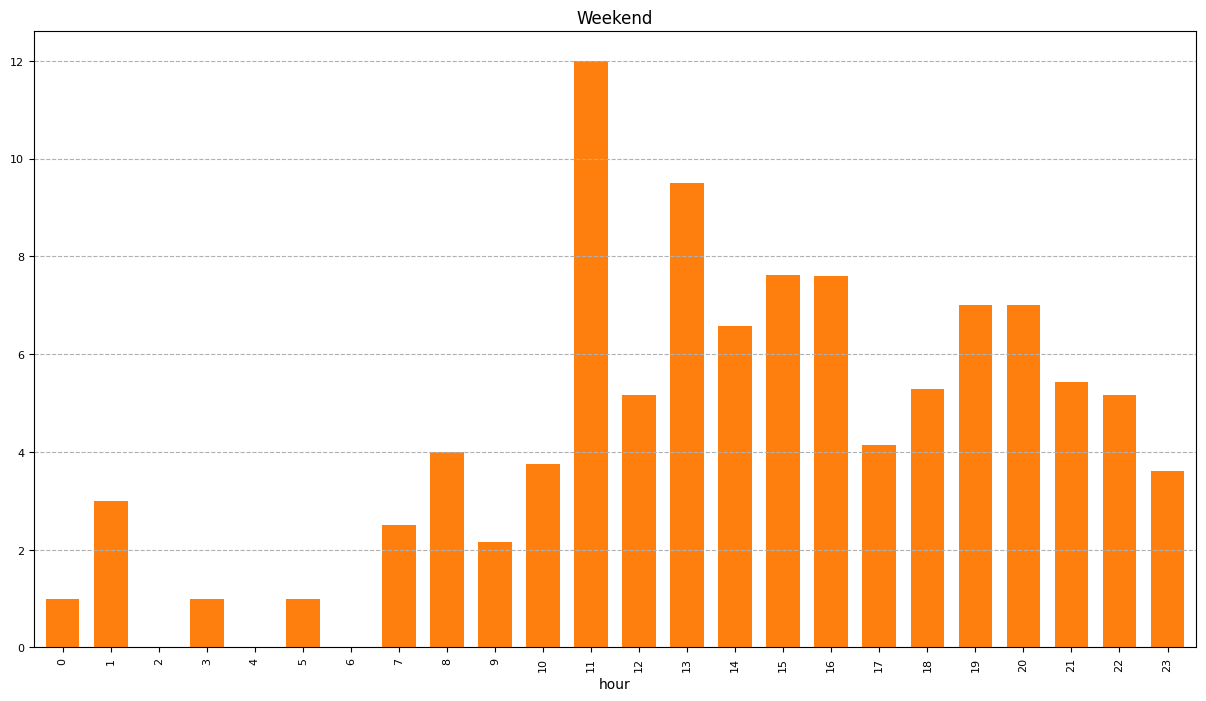

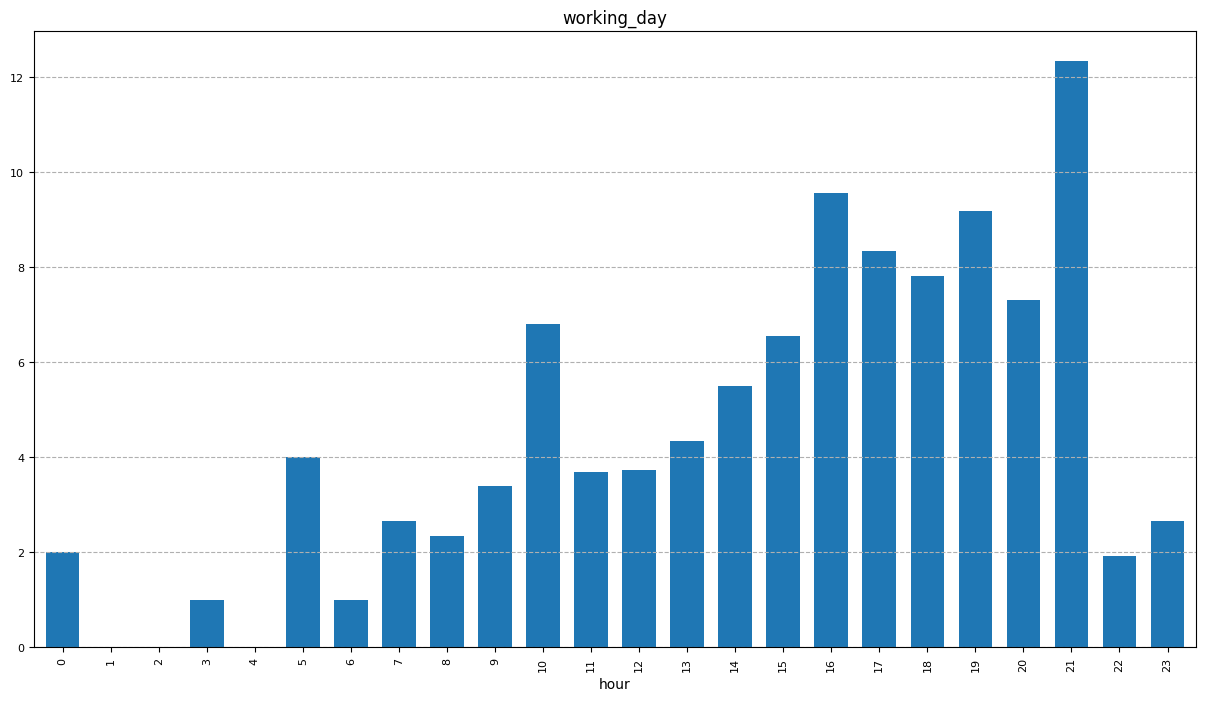

In [390]:
weekend_df = pd.DataFrame({'commits': weekend_avg}).fillna(0)

# График для выходных
ax1 = weekend_df.plot.bar(
    figsize=(15, 8),  # Размер графика
    color='#ff7f0e',  # Оранжевый
    width=0.7,
    title='Weekend',
    fontsize=8,
    legend=False
)
ax1.set_xticks(range(24))
ax1.set_xticklabels(range(24))
ax1.grid(axis='y', linestyle='--')

# Создаем DataFrame для рабочих дней
working_df = pd.DataFrame({'commits': working_avg}).fillna(0)

# График для рабочих дней
ax2 = working_df.plot.bar(
    figsize=(15, 8),
    color='#1f77b4',  # Синий
    width=0.7,
    title='working_day',
    fontsize=8,
    legend=False
)
ax2.set_xticks(range(24))
ax2.set_xticklabels(range(24))
ax2.grid(axis='y', linestyle='--')


In [ ]:
conn.close

In [391]:
max_weekday_hour = working_avg.idxmax()
max_weekend_hour = weekend_avg.idxmax()
print(max_weekday_hour)
print(max_weekend_hour)


21
11
